In [1]:
import uproot

import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.ROOT)
from BTVNanoCommissioning.utils.xs_scaler import collate
from BTVNanoCommissioning.utils.plot_utils import load_coffea
import numpy as np
from BTVNanoCommissioning.helpers.xsection import xsection
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt, mplhep as hep
%load_ext autoreload
%autoreload 2
from BTVNanoCommissioning.utils.plot_utils import (
    isin_dict,
    check_config,
    load_coffea,
    load_default,
    rebin_and_xlabel,
    plotratio,
    errband_opts,
    autoranger,
    rebin_hist
)
import numpy as np

In [ ]:
sumw = {}
scales={}
# lumi= #41500#19500 #16800 # #19500  #16800 #19500 
collect_var={}
lumi=19500
period="preVFP_UL16"
# output=load_coffea({"input":f"MC_HLT_corrsel_{period}_v00/*.coffea","lumi":lumi},True)

# data=load_coffea({"input":f"data_HLT_corrsel_{period}_v00/*.coffea"},False)
# output=load_coffea({"input":"MC_cluster_UL17_v01//*.coffea","lumi":lumi},True)

# for s in data.keys(): output[s]=data[s]

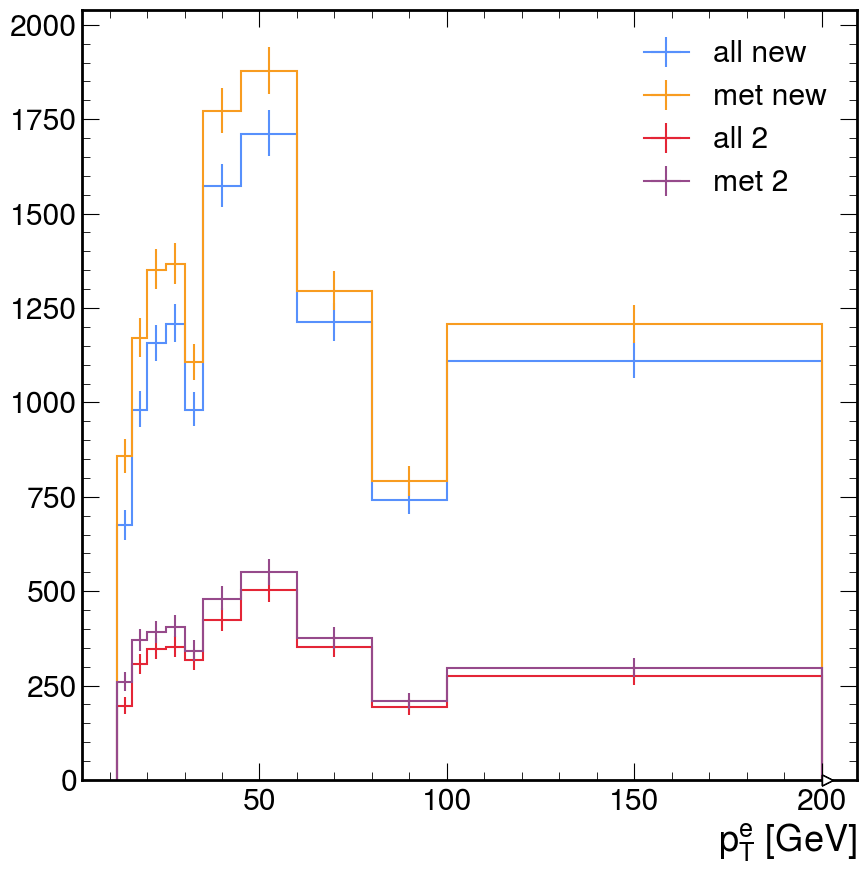

In [16]:
output_lcut=load_coffea({"input":"MC_HLT_met_preVFP_UL16_v04/*.coffea","lumi":lumi},True)
output_nometcut=load_coffea({"input":"MC_HLT_met_preVFP_UL16_v05/*.coffea","lumi":lumi},True)
output=load_coffea({"input":"MC_HLT_met_preVFP_UL16_v00/*.coffea","lumi":lumi},True)
mergemap={
    'ttbar':['TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8', 'TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8'],
}

collated=collate(output,mergemap)
collatedl=collate(output_lcut,mergemap)
collated2=collate(output_nometcut,mergemap)
# hep.histplot(collated['ttbar']['hist_all'][:,sum,sum,sum,sum,sum,0],label='all old')
# hep.histplot(collated['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,0],label='met old')
hep.histplot(collatedl['ttbar']['hist_all'][:,sum,sum,sum,sum,sum,0],label='all new')
hep.histplot(collatedl['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,0],label='met new')
hep.histplot(collated2['ttbar']['hist_all'][:,sum,sum,sum,sum,sum,2],label='all 2')
hep.histplot(collated2['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,2],label='met 2')
plt.legend()

In [8]:
collatedl['ttbar']['hist_all']

Hist(
  Variable([12, 16, 20, 25, 30, 35, 45, 60, 80, 100, 200], name='pt_e', label=' $p_{T}^{e}$ [GeV]'),
  Variable([12, 16, 20, 25, 30, 35, 45, 60, 80, 100, 200], name='pt_mu', label=' $p_{T}^{\\mu}$ [GeV]'),
  Variable([0, 0.5, 1, 1.442, 1.566, 2.5], name='abseta_e', label=' $|\\eta^{e}|$ [GeV]'),
  Variable([0, 0.5, 1, 1.442, 1.566, 2.5], name='abseta_mu', label=' $|\\eta^{\\mu}|$ [GeV]'),
  Variable([0, 10, 15, 20, 25, 30, 40], name='nvtx', label='nVtx'),
  Integer(0, 6, name='nj', label='# of jet'),
  StrCategory(['base', 'jet', 'cjet'], growth=True, name='cut'),
  storage=Weight()) # Sum: WeightedSum(value=22904.9, variance=46577.9) (WeightedSum(value=23758.1, variance=48308.9) with flow)

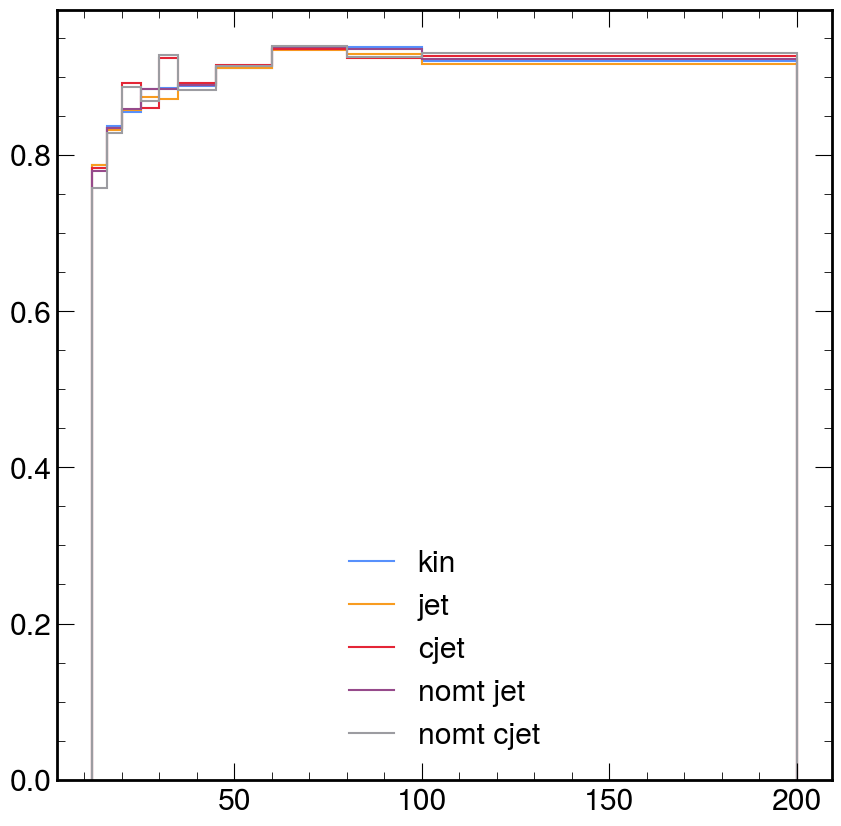

In [13]:
hep.histplot(collatedl['ttbar']['hist_all'][:,sum,sum,sum,sum,sum,0].values()/collatedl['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,0].values(),collatedl['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,0].axes[0].edges,label="kin")
hep.histplot(collatedl['ttbar']['hist_all'][:,sum,sum,sum,sum,sum,1].values()/collatedl['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,1].values(),collatedl['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,0].axes[0].edges,label="jet")
hep.histplot(collatedl['ttbar']['hist_all'][:,sum,sum,sum,sum,sum,2].values()/collatedl['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,2].values(),collatedl['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,0].axes[0].edges,label="cjet")
hep.histplot(collated2['ttbar']['hist_all'][:,sum,sum,sum,sum,sum,1].values()/collated2['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,1].values(),collatedl['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,0].axes[0].edges,label="nomt jet")
hep.histplot(collated2['ttbar']['hist_all'][:,sum,sum,sum,sum,sum,2].values()/collated2['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,2].values(),collatedl['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,0].axes[0].edges,label="nomt cjet")
# hep.histplot(collated['ttbar']['hist_all'][:,sum,sum,sum,sum,sum,0].values()/collated['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,0].values(),collatedl['ttbar']['hist_MET'][:,sum,sum,sum,sum,sum,0].axes[0].edges)
# hep.histplot(,label='met new')
plt.legend()

In [20]:
mergemap={
    'ttbar':['TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8', 'TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8'],
    # 'st':['ST_t-channel_antitop_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8', 'ST_tW_antitop_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8', 'ST_t-channel_top_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8', 'ST_tW_top_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8', 'ST_s-channel_4f_leptonDecays_TuneCP5_13TeV-amcatnlo-pythia8'],
    # "zjets":['DYJetsToLL_M-50_TuneCP5_13TeV-amcatnloFXFX-pythia8', 'DYJetsToLL_M-10to50_TuneCP5_13TeV-madgraphMLM-pythia8'],#, 'DYJetsToTauTauToMuTauh_M-50_TuneCP5_13TeV-madgraphMLM-pythia8'], 
    # 'vv':['WZ_TuneCP5_13TeV-pythia8', 'WW_TuneCP5_13TeV-pythia8', 'ZZ_TuneCP5_13TeV-pythia8'],
     'MC':['TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8', 'TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8',
             'ST_t-channel_antitop_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8', 'ST_tW_antitop_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8', 
          'ST_t-channel_top_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8', 'ST_tW_top_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8', 
          'ST_s-channel_4f_leptonDecays_TuneCP5_13TeV-amcatnlo-pythia8','DYJetsToLL_M-50_TuneCP5_13TeV-amcatnloFXFX-pythia8', 'DYJetsToLL_M-10to50_TuneCP5_13TeV-madgraphMLM-pythia8',
          'WZ_TuneCP5_13TeV-pythia8', 'WW_TuneCP5_13TeV-pythia8', 'ZZ_TuneCP5_13TeV-pythia8'],
    "data_obs":
    ['METRun2016B-ver2_HIPM_UL2016_MiniAODv2_NanoAODv', 'METRun2016C-HIPM_UL2016_MiniAODv2_NanoAODv', 'METRun2016D-HIPM_UL2016_MiniAODv2_NanoAODv', 'METRun2016E-HIPM_UL2016_MiniAODv2_NanoAODv', 'METRun2016F-HIPM_UL2016_MiniAODv2_NanoAODv'],
     # ['METRun2016F-UL2016_MiniAODv2_NanoAODv', 'METRun2016G-UL2016_MiniAODv2_NanoAODv', 'METRun2016H-UL2016_MiniAODv2_NanoAODv'],
    # ['METRun2017B-UL2017_MiniAODv2_NanoAODv', 'METRun2017C-UL2017_MiniAODv2_NanoAODv', 'METRun2017D-UL2017_MiniAODv2_NanoAODv', 'METRun2017E-UL2017_MiniAODv2_NanoAODv', 'METRun2017F-UL2017_MiniAODv2_NanoAODv'],
    # ['METRun2018A-UL2018_MiniAODv2_NanoAODv9_GT3', 'METRun2018B-UL2018_MiniAODv2_NanoAODv9_GT3', 'METRun2018C-UL2018_MiniAODv2_NanoAODv9_GT3', 'METRun2018D-UL2018_MiniAODv2_NanoAODv9_GT3'],
    'data_lep':   
    ["MuonEG_Run2016B-ver1_HIPM_UL2016_MiniAODv2_NanoAODv9-v2", "MuonEG_Run2016B-ver2_HIPM_UL2016_MiniAODv2_NanoAODv9-v2","MuonEG_Run2016C-HIPM_UL2016_MiniAODv2_NanoAODv9-v2","MuonEG_Run2016D-HIPM_UL2016_MiniAODv2_NanoAODv9-v2","MuonEG_Run2016E-HIPM_UL2016_MiniAODv2_NanoAODv9-v2","MuonEG_Run2016F-HIPM_UL2016_MiniAODv2_NanoAODv9-v2"]
    # ["MuonEG_Run2016F-UL2016_MiniAODv2_NanoAODv9-v1","MuonEG_Run2016G-UL2016_MiniAODv2_NanoAODv9-v1","MuonEG_Run2016H-UL2016_MiniAODv2_NanoAODv9-v1"]
    # [ "MuonEG_Run2017B-UL2017_MiniAODv2_NanoAODv9-v1","MuonEG_Run2017C-UL2017_MiniAODv2_NanoAODv9-v1","MuonEG_Run2017D-UL2017_MiniAODv2_NanoAODv9-v1","MuonEG_Run2017F-UL2017_MiniAODv2_NanoAODv9-v1","MuonEG_Run2017E-UL2017_MiniAODv2_NanoAODv9-v1",]
    # ["MuonEG_Run2018A-UL2018_MiniAODv2_NanoAODv9-v1","MuonEG_Run2018B-UL2018_MiniAODv2_NanoAODv9-v1","MuonEG_Run2018C-UL2018_MiniAODv2_NanoAODv9-v1","MuonEG_Run2018D-UL2018_MiniAODv2_NanoAODv9-v1"]
}

collated=collate(output,mergemap)
labels={'pt_e':"$p_T^{e}$",'pt_mu':"$p_T^{\\mu}$","abseta_e":"$|\\eta^{e}|$","abseta_mu":"$|\\eta^{\\mu}|$","nj":'# of jets',"nbj":'# of b-jets',"nvtx":"# of vertices","met":"MET"}
ext={"base":"baseline","llptsel":"+ $p_T^{\\ell\\ell}$","mtsel":"+m_T^{\\ell1}>30","metsel":"+MET>30",
    "metdphisel":"+$|\Delta\phi(TkMET,MET)|<0.5$","jet":"+$\geq$1 jets","cjet":"+$\geq$1 c-jets",'bljet':"+$\geq$1 otherjets"}
color_map={"ttbar":"#38A6A5"}#,"st":"#73AF48","vv":"#EDAD08","zjets":"#554e99"}#,"higgs":"#CC503E","hc":"#666666"}
name_map={'ttbar':"TT"}#,"st":"ST","zjets":"Z+jets","vv":'VV'}#,"higgs":"Higgs","hc":"H+c"}

In [33]:
name_map={'ttbar':"TT"}

In [1]:
# collated['data_obs']['hist_all'].axesaxes.name


plt.style.use(hep.style.ROOT)
for var in ['hist_lep']:
    if 'sumw' in var:continue
    # if 'hist_lep' !=var: continue
    for s in collated['ttbar']['hist_MET'].axes.name:
        if s=="cut" :continue
        if s!="pt_e" and s!="pt_mu" :continue
        axis={a:sum for a in collated['ttbar']['hist_all'].axes.name if s!=a}   
        for i in range(collated['data_obs']['hist_all'].axes[-1].size):
            axis['cut']=collated['data_obs']['hist_all'].axes[-1].value(i)
            # print()abs
            # print(axis['cut'])
            # if i!=0:continue  
            # if axis['cut']!='metsel': continue
            fig, ((ax), (rax)) = plt.subplots(
                    2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
                )
            hep.cms.label(
                    "work in progress",
                    data=True,
                    lumi=lumi/1000,
                    com="13",
                    loc=0,
                    ax=ax,
                )
            
            hep.histplot([collated[ss][var][axis]for ss in color_map.keys()] ,histtype='fill',color=[color_map[ss] for ss in color_map.keys()],label=[name_map[ss] for ss in color_map.keys()],stack=True,ax=ax,flow="show")
            hep.histplot(collated["data_obs"][var][axis],histtype='errorbar',color='k',ax=ax,flow="show")
            # print(collated["data_obs"][var][axis],collated["ttbar"][var][axis])
            hmc=collated['ttbar'][var][axis]
            at = AnchoredText(f"{ext[collated['data_obs']['hist_all'].axes[-1].value(i)]}\n{var}",  frameon=False,loc=2)
            ax.add_artist(at)
            # for ss in color_map.keys():
            #     if ss == 'ttbar':continue
            #     hmc=hmc+collated[ss][var][axis]
            plotratio(collated['data_obs'][var][axis],hmc,ax=rax)
            ax.legend()
            rax.set_ylim(0.9,1.1)
            ax.set_ylim(bottom=0)
            ax.set_xlabel(None)
            rax.set_ylabel("data/MC")
            ax.set_ylabel("Events")
            hep.mpl_magic(ax=ax)
            rax.set_xlabel(labels[s])
            
            # ax.set_xlim(10,100)
    # hep.histplot([collated[s][axis] for s in collated.keys() if 'data' not in s],label=[s in collated.keys if 'data' not in s])

NameError: name 'plt' is not defined

{'pt_mu': <built-in function sum>, 'abseta_e': <built-in function sum>, 'abseta_mu': <built-in function sum>, 'nvtx': <built-in function sum>, 'nj': <built-in function sum>, 'cut': <built-in function sum>}
False
False
(2, 10)


TypeError: 'numpy.ndarray' object is not callable

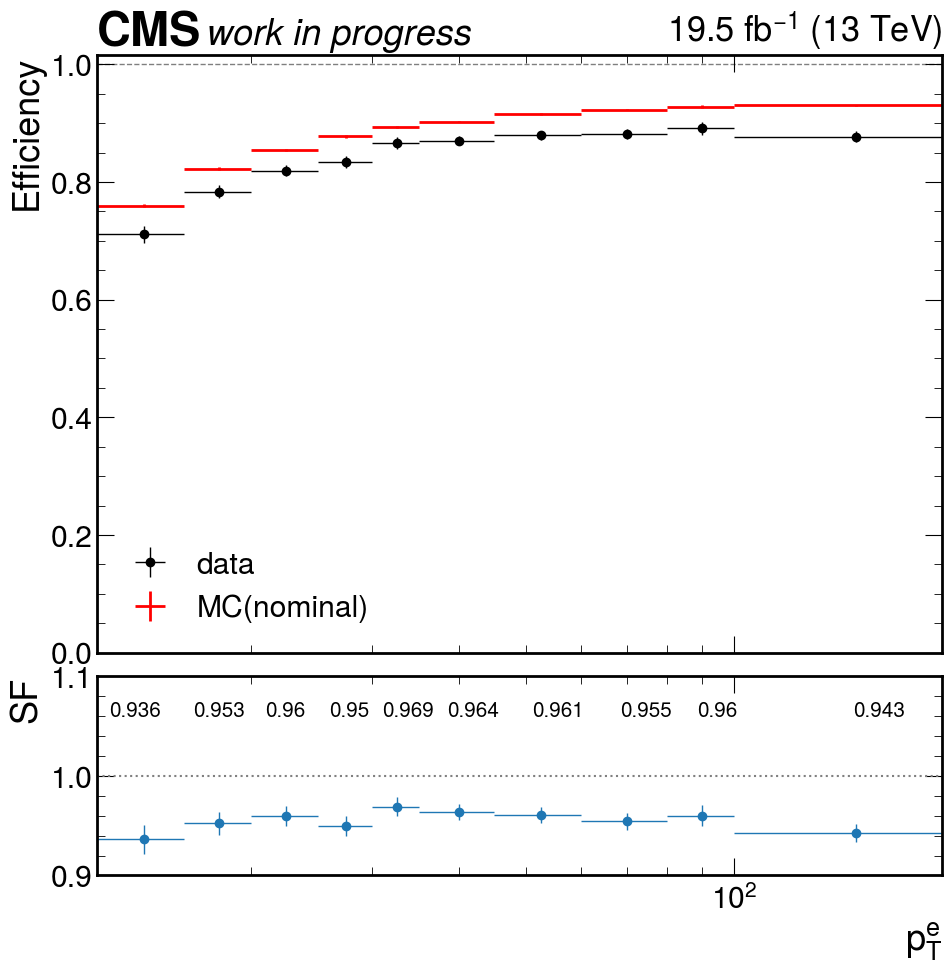

In [4]:
plt.style.use(hep.style.ROOT)
SF={}
from BTVNanoCommissioning.utils.plot_utils import normal_interval
SF['base']={}
for s in collated['ttbar']['hist_all'].axes.name:
    if s=="cut" :continue
    if s!="pt_e" and s!="pt_mu" :continue
    axis={a:sum for a in collated['ttbar']['hist_all'].axes.name if s!=a}   
    print(axis)
    for i in range(collated['data_obs']['hist_all'].axes[-1].size):
        
        axis['cut']=collated['data_obs']['hist_all'].axes[-1].value(i)
        # dump SFs
        
        SF[axis['cut']][s]={}
        
        if axis['cut']!='base': continue
        fig, ((ax), (rax)) = plt.subplots(
                2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
            )
        fig.subplots_adjust(hspace=0.06, top=0.92, bottom=0.1, right=0.97)
        
        hall=collated['ttbar']['hist_all'][axis]
        hMET=collated['ttbar']['hist_MET'][axis]
        at = AnchoredText("",  frameon=False,loc=2)
        
        for ss in color_map.keys():
            if ss == 'ttbar':continue
            hall=hall+collated[ss]['hist_all'][axis]
            hMET=hMET+collated[ss]['hist_MET'][axis]
        
        _,data,data_err=plotratio(collated["data_obs"]['hist_all'][axis],
                  collated["data_obs"]['hist_MET'][axis],
                  ax=ax,unc="efficiency",
                  label="data",xerr=True,denom_fill_opts=None
                 )
        _,MC,MC_err=plotratio(hall,hMET,ax=ax,
                              clear=False,unc="efficiency",label="MC(nominal)",xerr=True,
                              error_opts={"lw":2,"marker":None,"color":"r"},denom_fill_opts=None)
        ax.add_artist(at)
        
        for b in range(len(data/MC)):
            SF[axis['cut']][s][f"pt:[{hall.axes[0].edges[b]},{hall.axes[0].edges[b+1]}]"]={}
            SF[axis['cut']][s][f"pt:[{hall.axes[0].edges[b]},{hall.axes[0].edges[b+1]}]"]['value']=(data/MC)[b]
            SF[axis['cut']][s][f"pt:[{hall.axes[0].edges[b]},{hall.axes[0].edges[b+1]}]"]['stat_error']=np.sqrt(MC_err**2+data_err**2)[0][b]
        # plotratio(collated["data_obs"]['hist_all'][axis]/collated["data_obs"]['hist_MET'][axis],hmc,ax=rax)
        ax.legend()
        hep.cms.label(
                "work in progress",
                data=True,
                lumi=lumi/1000,
                com="13",
                loc=0,
                ax=ax,
            )
        rax.set_ylim(0.9,1.1)
        ax.set_ylim(bottom=0)
        ax.set_xlabel(None)
        rax.set_ylabel("SF")
        ax.set_ylabel("Efficiency")
        # hep.mpl_magic(ax=ax)
        rax.axhline(1.,ls=':',color='gray')
        rax.set_xlabel(labels[s])
        if "pt" in s: ax.semilogx()
        print(np.shape(MC_err))
        # print(data/MC,np.sqrt(MC_err**2+data_err**2)[0]==np.sqrt(MC_err**2+data_err**2)[1])
        for r in range(0,len(hall.axes[0].centers)):
            if "eta" in s or "nj"==s:
                rax.text(hall.axes[0].centers[r],1.06,round((data/MC)[r],3),size=15)
                rax.text(hall.axes[0].centers[r],1.03,f"$\pm${round(np.sqrt(MC_err**2+data_err**2)[0][r],3)}",size=13)
            else:
                rax.text(hall.axes[0].centers[r]-1.5,1.06,round((data/MC)[r],3),size=15)
                # rax.text(hall.axes[0].centers[r]-2.1,1.03,f"$\pm${round(np.sqrt(MC_err**2+data_err**2+(1.-(MET_eff*lep_eff/all_eff)[r])**2)[0][r],3)}",size=13)
        rax.errorbar(
            x=hall.axes[0].centers,
            y=data/MC,
            xerr=(hall.axes[0].centers-hall.axes[0].edges[:-1]),
            yerr=np.sqrt(MC_err**2+data_err**2),lw=1,marker='o',ls="none",color='tab:blue')
        print(hall.axes[0].edges())
        # plt.savefig(f"{period}_{s}_syst.pdf")
        
        # ax.set_xlim(10,100)
# hep.histplot([collated[s][axis] for s in collated.keys() if 'data' not in s],label=[s in collated.keys if 'data' not in s])

{'pt_mu': <built-in function sum>, 'abseta_e': <built-in function sum>, 'abseta_mu': <built-in function sum>, 'nvtx': <built-in function sum>, 'nj': <built-in function sum>, 'cut': <built-in function sum>}
False
False
(2, 10)


TypeError: 'numpy.ndarray' object is not callable

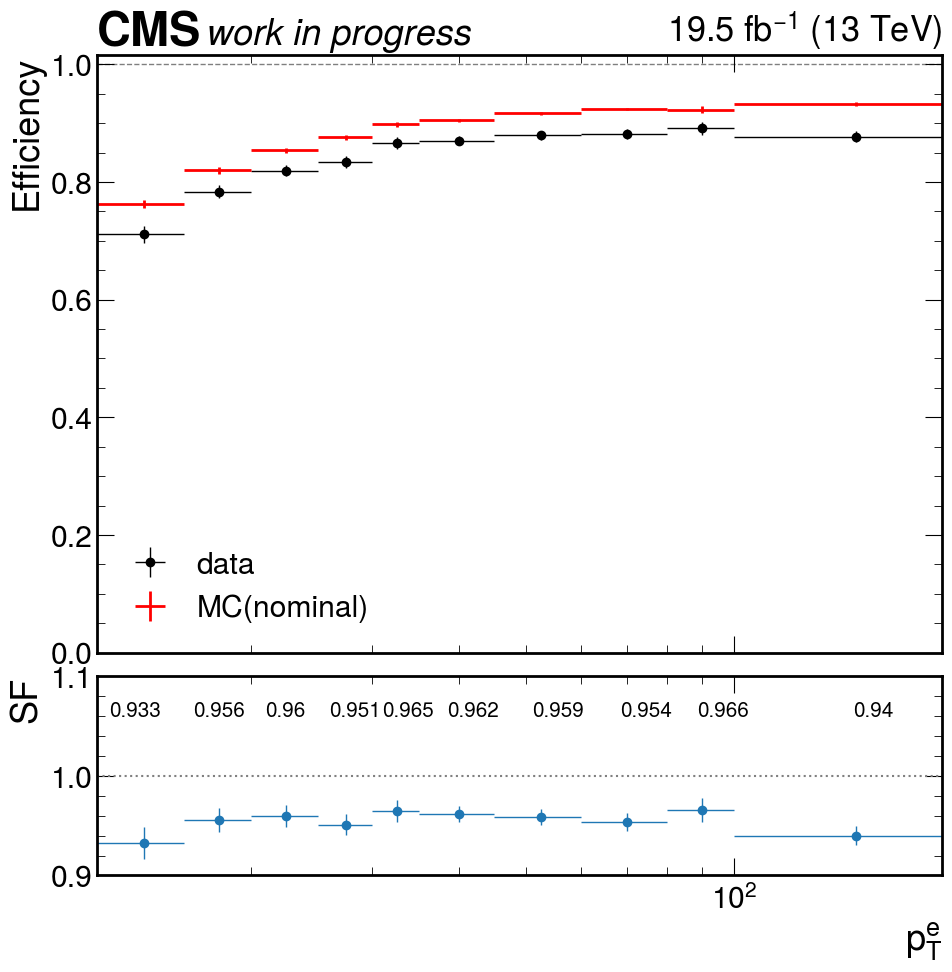

In [17]:
plt.style.use(hep.style.ROOT)
SF={}
from BTVNanoCommissioning.utils.plot_utils import normal_interval
SF['base']={}
for s in collated['ttbar']['hist_all'].axes.name:
    if s=="cut" :continue
    if s!="pt_e" and s!="pt_mu" :continue
    axis={a:sum for a in collated['ttbar']['hist_all'].axes.name if s!=a}   
    print(axis)
    for i in range(collated['data_obs']['hist_all'].axes[-1].size):
        
        axis['cut']=collated['data_obs']['hist_all'].axes[-1].value(i)
        # dump SFs
        
        SF[axis['cut']][s]={}
        
        if axis['cut']!='base': continue
        fig, ((ax), (rax)) = plt.subplots(
                2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
            )
        fig.subplots_adjust(hspace=0.06, top=0.92, bottom=0.1, right=0.97)
        
        hall=collated['ttbar']['hist_all'][axis]
        hMET=collated['ttbar']['hist_MET'][axis]
        at = AnchoredText("",  frameon=False,loc=2)
        
        for ss in color_map.keys():
            if ss == 'ttbar':continue
            hall=hall+collated[ss]['hist_all'][axis]
            hMET=hMET+collated[ss]['hist_MET'][axis]
        
        _,data,data_err=plotratio(collated["data_obs"]['hist_all'][axis],
                  collated["data_obs"]['hist_MET'][axis],
                  ax=ax,unc="efficiency",
                  label="data",xerr=True,denom_fill_opts=None
                 )
        _,MC,MC_err=plotratio(hall,hMET,ax=ax,
                              clear=False,unc="efficiency",label="MC(nominal)",xerr=True,
                              error_opts={"lw":2,"marker":None,"color":"r"},denom_fill_opts=None)
        ax.add_artist(at)
        
        for b in range(len(data/MC)):
            SF[axis['cut']][s][f"pt:[{hall.axes[0].edges[b]},{hall.axes[0].edges[b+1]}]"]={}
            SF[axis['cut']][s][f"pt:[{hall.axes[0].edges[b]},{hall.axes[0].edges[b+1]}]"]['value']=(data/MC)[b]
            SF[axis['cut']][s][f"pt:[{hall.axes[0].edges[b]},{hall.axes[0].edges[b+1]}]"]['stat_error']=np.sqrt(MC_err**2+data_err**2)[0][b]
        # plotratio(collated["data_obs"]['hist_all'][axis]/collated["data_obs"]['hist_MET'][axis],hmc,ax=rax)
        ax.legend()
        hep.cms.label(
                "work in progress",
                data=True,
                lumi=lumi/1000,
                com="13",
                loc=0,
                ax=ax,
            )
        rax.set_ylim(0.9,1.1)
        ax.set_ylim(bottom=0)
        ax.set_xlabel(None)
        rax.set_ylabel("SF")
        ax.set_ylabel("Efficiency")
        # hep.mpl_magic(ax=ax)
        rax.axhline(1.,ls=':',color='gray')
        rax.set_xlabel(labels[s])
        if "pt" in s: ax.semilogx()
        print(np.shape(MC_err))
        # print(data/MC,np.sqrt(MC_err**2+data_err**2)[0]==np.sqrt(MC_err**2+data_err**2)[1])
        for r in range(0,len(hall.axes[0].centers)):
            if "eta" in s or "nj"==s:
                rax.text(hall.axes[0].centers[r],1.06,round((data/MC)[r],3),size=15)
                rax.text(hall.axes[0].centers[r],1.03,f"$\pm${round(np.sqrt(MC_err**2+data_err**2)[0][r],3)}",size=13)
            else:
                rax.text(hall.axes[0].centers[r]-1.5,1.06,round((data/MC)[r],3),size=15)
                # rax.text(hall.axes[0].centers[r]-2.1,1.03,f"$\pm${round(np.sqrt(MC_err**2+data_err**2+(1.-(MET_eff*lep_eff/all_eff)[r])**2)[0][r],3)}",size=13)
        rax.errorbar(
            x=hall.axes[0].centers,
            y=data/MC,
            xerr=(hall.axes[0].centers-hall.axes[0].edges[:-1]),
            yerr=np.sqrt(MC_err**2+data_err**2),lw=1,marker='o',ls="none",color='tab:blue')
        print(hall.axes[0].edges())
        plt.savefig(f"{period}_{s}_syst.pdf")
        
        # ax.set_xlim(10,100)
# hep.histplot([collated[s][axis] for s in collated.keys() if 'data' not in s],label=[s in collated.keys if 'data' not in s])

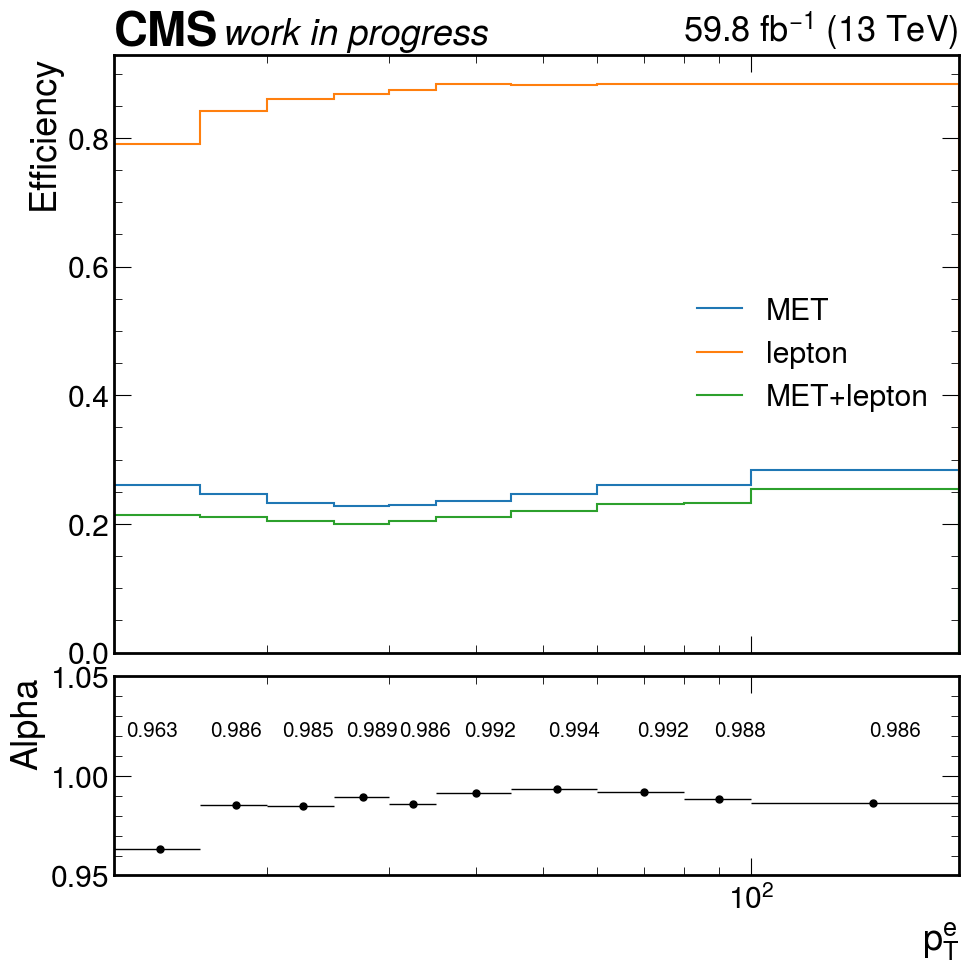

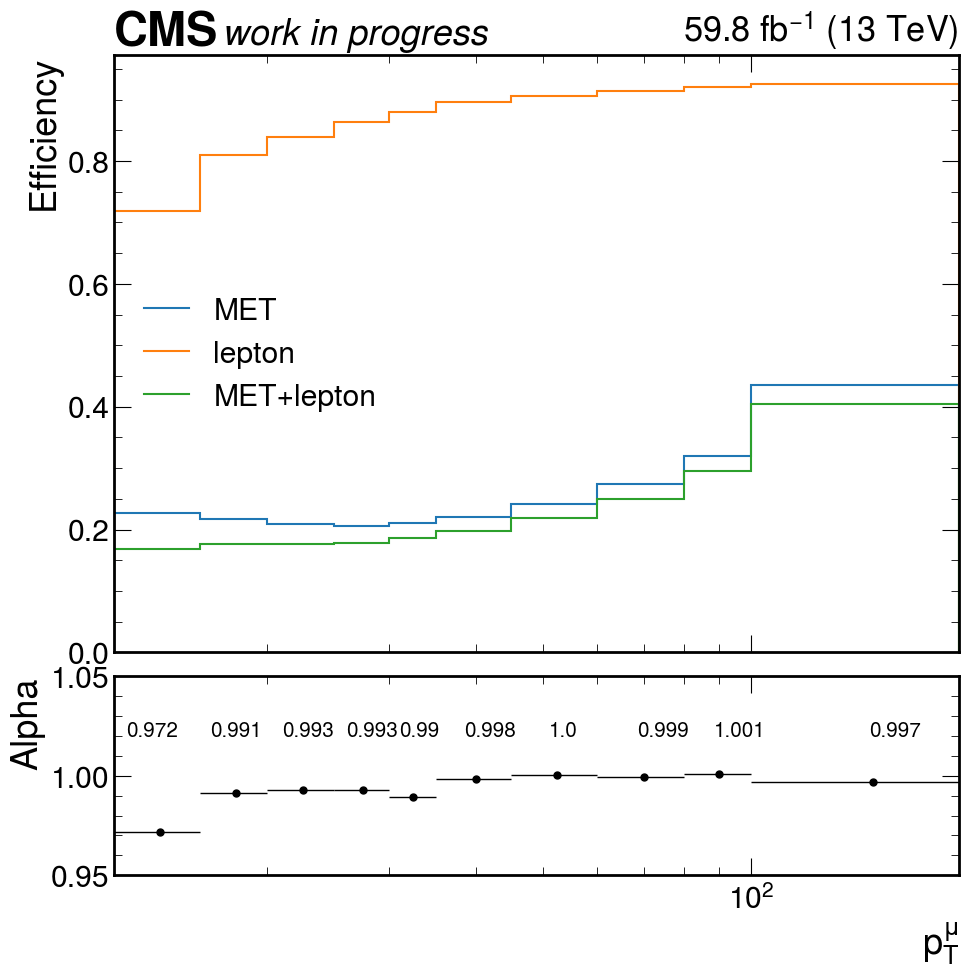

In [13]:
for bin in ["pt_e","pt_mu"]:
    fig, ((ax), (rax)) = plt.subplots(
                        2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
                    )
    fig.subplots_adjust(hspace=0.06, top=0.92, bottom=0.1, right=0.97)
    
    hep.cms.label(
                        "work in progress",
                        data=True,
                        lumi=lumi/1000,
                        com="13",
                        loc=0,
                        ax=ax,
                    )
    axes={bin:sum, 'abseta_e': sum, 'abseta_mu': sum, 'nvtx': sum, 'nj':sum, 'cut': 'base'}
    # axes={'pt_mu':sum, 'abseta_e': sum, 'abseta_mu': sum, 'nvtx': sum, 'nj':sum, 'cut': 'base'}
    edges=collated['MC']['hist_MET'][axes].axes[0].edges
    MET_eff=collated['MC']['hist_MET'][axes].values()/collated['MC']['hist_no'][axes].values()
    lep_eff=collated['MC']['hist_lep'][axes].values()/collated['MC']['hist_no'][axes].values()
    all_eff=collated['MC']['hist_all'][axes].values()/collated['MC']['hist_no'][axes].values()
    hep.histplot(MET_eff,edges,label="MET",ax=ax,color='tab:blue')#,yerr=True)
    hep.histplot(lep_eff,edges,label="lepton",ax=ax,color='tab:orange')
    hep.histplot(all_eff,edges,label="MET+lepton",ax=ax,color='tab:green')#,yerr=True))
    ax.legend()
    ax.set_ylim()
    ax.set_ylabel("Efficiency")
    ax.semilogx()
    ax.set_xlim(edges[0],edges[-1])
    hep.histplot(MET_eff*lep_eff/all_eff,edges,ax=rax,histtype='errorbar',color='k',yerr=False,xerr=True)
    rax.set_ylim(0.95,1.05)
    rax.set_ylabel("Alpha")
    rax.set_xlabel(labels[bin])
    
    for r in range(0,len(collated['MC']['hist_MET'][axes].axes[0].centers)):
        rax.text(collated['MC']['hist_MET'][axes].axes[0].centers[r]-1.5,1.02,round((MET_eff*lep_eff/all_eff)[r],3),size=15)
        SF['base'][bin][f"pt:[{edges[r]},{edges[r+1]}]"]['corr_error']=1.-(MET_eff*lep_eff/all_eff)[r]
        SF['base'][bin][f"pt:[{edges[r]},{edges[r+1]}]"]['error'] = np.sqrt(SF['base'][bin][f"pt:[{edges[r]},{edges[r+1]}]"]['corr_error']**2+SF['base'][bin][f"pt:[{edges[r]},{edges[r+1]}]"]['stat_error']**2)
        # rax.text(collated['MC']['hist_MET'][axes].centers[r]-2.1,1.03,f"$\pm${round(np.sqrt(MC_err**2+data_err**2)[0][r],3)}",size=13)
    plt.savefig(f"corr_{bin}_{period}_{s}.pdf")     

In [ ]:
for bin in ["pt_e","pt_mu"]:
    fig, ((ax), (rax)) = plt.subplots(
                        2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
                    )
    fig.subplots_adjust(hspace=0.06, top=0.92, bottom=0.1, right=0.97)
    
    hep.cms.label(
                        "work in progress",
                        data=True,
                        lumi=lumi/1000,
                        com="13",
                        loc=0,
                        ax=ax,
                    )
    axes={bin:sum, 'abseta_e': sum, 'abseta_mu': sum, 'nvtx': sum, 'nj':sum, 'cut': 'base'}
    # axes={'pt_mu':sum, 'abseta_e': sum, 'abseta_mu': sum, 'nvtx': sum, 'nj':sum, 'cut': 'base'}
    edges=collated['MC']['hist_MET'][axes].axes[0].edges
    MET_eff=collated['MC']['hist_MET'][axes].values()#/collated['MC']['hist_no'][axes].values()
    lep_eff=collated['MC']['hist_lep'][axes].values()#/collated['MC']['hist_no'][axes].values()
    all_eff=collated['MC']['hist_all'][axes].values()/collated['MC']['hist_no'][axes].values()
    hep.histplot(MET_eff,edges,label="MET",ax=ax,color='tab:blue')#,yerr=True)
    hep.histplot(lep_eff,edges,label="lepton",ax=ax,color='tab:orange')
    hep.histplot(all_eff,edges,label="MET+lepton",ax=ax,color='tab:green')#,yerr=True))
    ax.legend()
    ax.set_ylim()
    ax.set_ylabel("Efficiency")
    ax.semilogx()
    ax.set_xlim(edges[0],edges[-1])
    hep.histplot(MET_eff*lep_eff/all_eff,edges,ax=rax,histtype='errorbar',color='k',yerr=False,xerr=True)
    rax.set_ylim(0.95,1.05)
    rax.set_ylabel("Alpha")
    rax.set_xlabel(labels[bin])
    
    for r in range(0,len(collated['MC']['hist_MET'][axes].axes[0].centers)):
        rax.text(collated['MC']['hist_MET'][axes].axes[0].centers[r]-1.5,1.02,round((MET_eff*lep_eff/all_eff)[r],3),size=15)
        SF['base'][bin][f"pt:[{edges[r]},{edges[r+1]}]"]['corr_error']=1.-(MET_eff*lep_eff/all_eff)[r]
        SF['base'][bin][f"pt:[{edges[r]},{edges[r+1]}]"]['error'] = np.sqrt(SF['base'][bin][f"pt:[{edges[r]},{edges[r+1]}]"]['corr_error']**2+SF['base'][bin][f"pt:[{edges[r]},{edges[r+1]}]"]['stat_error']**2)
        # rax.text(collated['MC']['hist_MET'][axes].centers[r]-2.1,1.03,f"$\pm${round(np.sqrt(MC_err**2+data_err**2)[0][r],3)}",size=13)
    plt.savefig(f"corr_{bin}_{period}_{s}.pdf")     

In [41]:
import json
json_object = json.dumps(SF, indent=4)
 
# Writing to sample.json
with open(f"{period}_{s}_HLTSF.histo.json", "w") as outfile:
    outfile.write(json_object)

In [11]:
f=json.load(open(f"{period}_{s}_HLTSF.histo.json"))
f2=json.load(open(f"src/BTVNanoCommissioning/data/LSF/2016preVFP_UL/{period}_{s}_HLTSF.histo.json"))


In [19]:
new,old={},{}

new['value_e']=[f['base']['pt_e'][k]['value'] for k in f['base']['pt_e'].keys()]
new['value_mu']=[f['base']['pt_mu'][k]['value'] for k in f['base']['pt_mu'].keys()]
new['err_e']=[f['base']['pt_e'][k]['error'] for k in f['base']['pt_e'].keys()]
new['err_mu']=[f['base']['pt_mu'][k]['error'] for k in f['base']['pt_mu'].keys()]
old['value_e']=[f2['base']['pt_e'][k]['value'] for k in f2['base']['pt_e'].keys()]
old['value_mu']=[f2['base']['pt_mu'][k]['value'] for k in f2['base']['pt_mu'].keys()]
old['err_e']=[f2['base']['pt_e'][k]['error'] for k in f2['base']['pt_e'].keys()]
old['err_mu']=[f2['base']['pt_mu'][k]['error'] for k in f2['base']['pt_mu'].keys()]


array([1.00215343, 0.99888302, 0.99563477, 0.99368792, 0.99957283,
       1.00624217, 0.99645296, 0.99547802, 0.99588647, 0.98718188])

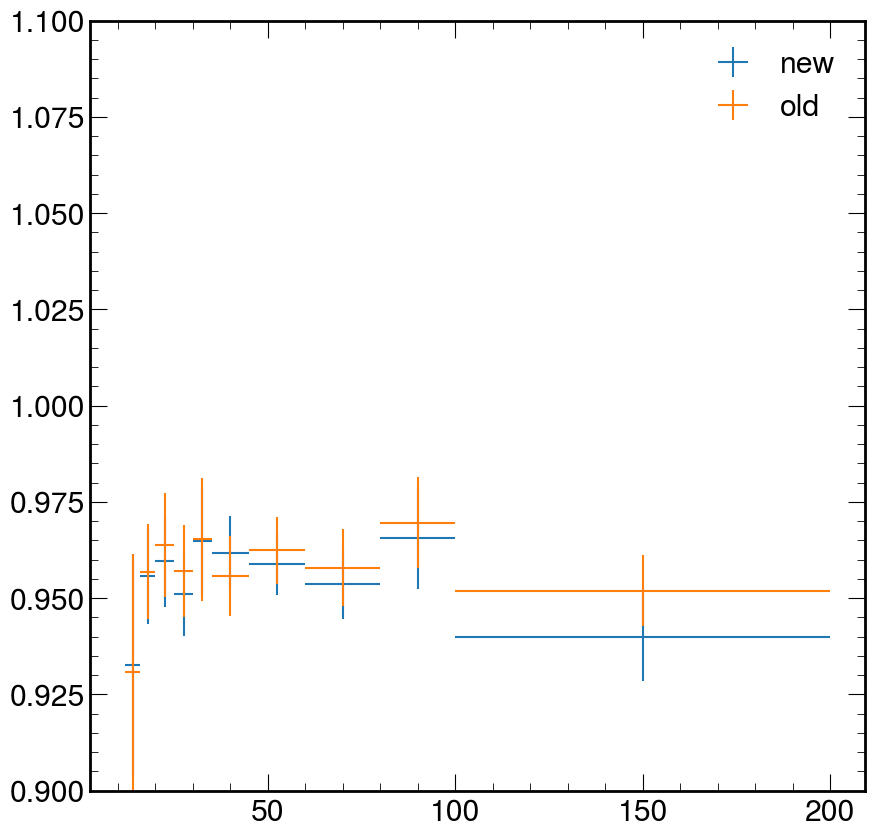

In [43]:
import matplotlib.pyplot as plt
plt.errorbar((edges[1:]+edges[:-1])/2.,new['value_e'],xerr=edges[1:]-(edges[1:]+edges[:-1])/2.,yerr=new['err_e'],ls='',label='new')
plt.errorbar((edges[1:]+edges[:-1])/2.,old['value_e'],xerr=edges[1:]-(edges[1:]+edges[:-1])/2.,yerr=old['err_e'],ls='',label='old')
import numpy as np

plt.legend()
plt.ylim(0.9,1.1)
np.array(new['value_e'])/np.array(old['value_e'])

array([1.00179438, 1.00107535, 0.99801309, 0.99440929, 0.99965564,
       0.99058756, 0.9984738 , 0.99568906, 0.99780583, 1.00129994])

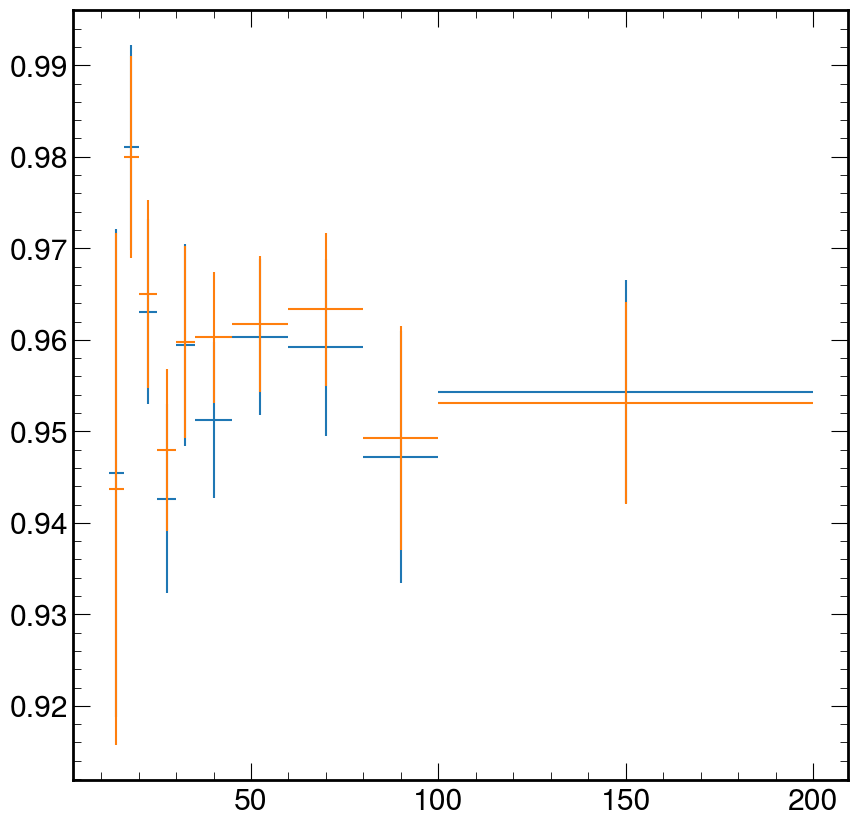

In [44]:
plt.errorbar((edges[1:]+edges[:-1])/2.,new['value_mu'],xerr=edges[1:]-(edges[1:]+edges[:-1])/2.,yerr=new['err_mu'],ls='')
plt.errorbar((edges[1:]+edges[:-1])/2.,old['value_mu'],xerr=edges[1:]-(edges[1:]+edges[:-1])/2.,yerr=old['err_mu'],ls='')
np.array(new['value_mu'])/np.array(old['value_mu'])


In [5]:
newhist={}
for unc in ["nj_up","nj_dn","nvtx_up","nvtx_dn",'abseta_e_up','abseta_e_dn','abseta_mu_up',"abseta_mu_dn"]:
    
    newhist[unc] = {}
    for s in collated.keys():
        newhist[unc][s] = {}
        for var in collated[s].keys():
            if var=='sumw':continue
            if 'nj' in unc: newhist[unc][s][var] = rebin_hist(collated[s][var],'nj',[0,3,6])
            if 'nvtx' in unc :newhist[unc][s][var] = rebin_hist(collated[s][var],'nvtx',[0,20,40])
            if '_e'  in unc:newhist[unc][s][var] = rebin_hist(collated[s][var],'abseta_e',[0,1.442,1.566,2.5])
            if '_mu'  in unc:newhist[unc][s][var] = rebin_hist(collated[s][var],'abseta_mu',[0,1.442,1.566,2.5])

In [6]:
color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

In [17]:

from BTVNanoCommissioning.utils.plot_utils import (
    isin_dict,
    check_config,
    load_coffea,
    load_default,
    rebin_and_xlabel,
    plotratio,
    errband_opts,
    autoranger,
    rebin_hist
)

/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:552: RuntimeWarning: invalid value encountered in divide
  rsumw = sumw_num / sumw_denom
/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:378: RuntimeWarning: invalid value encountered in divide
  eff = pw / tw
/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:591: RuntimeWarning: invalid value encountered in divide
  denom_unc = poisson_interval(unity, sumw2_denom / sumw_denom**2)


(2, 10)


/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:552: RuntimeWarning: invalid value encountered in divide
  rsumw = sumw_num / sumw_denom
/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:378: RuntimeWarning: invalid value encountered in divide
  eff = pw / tw
/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:591: RuntimeWarning: invalid value encountered in divide
  denom_unc = poisson_interval(unity, sumw2_denom / sumw_denom**2)


(2, 10)


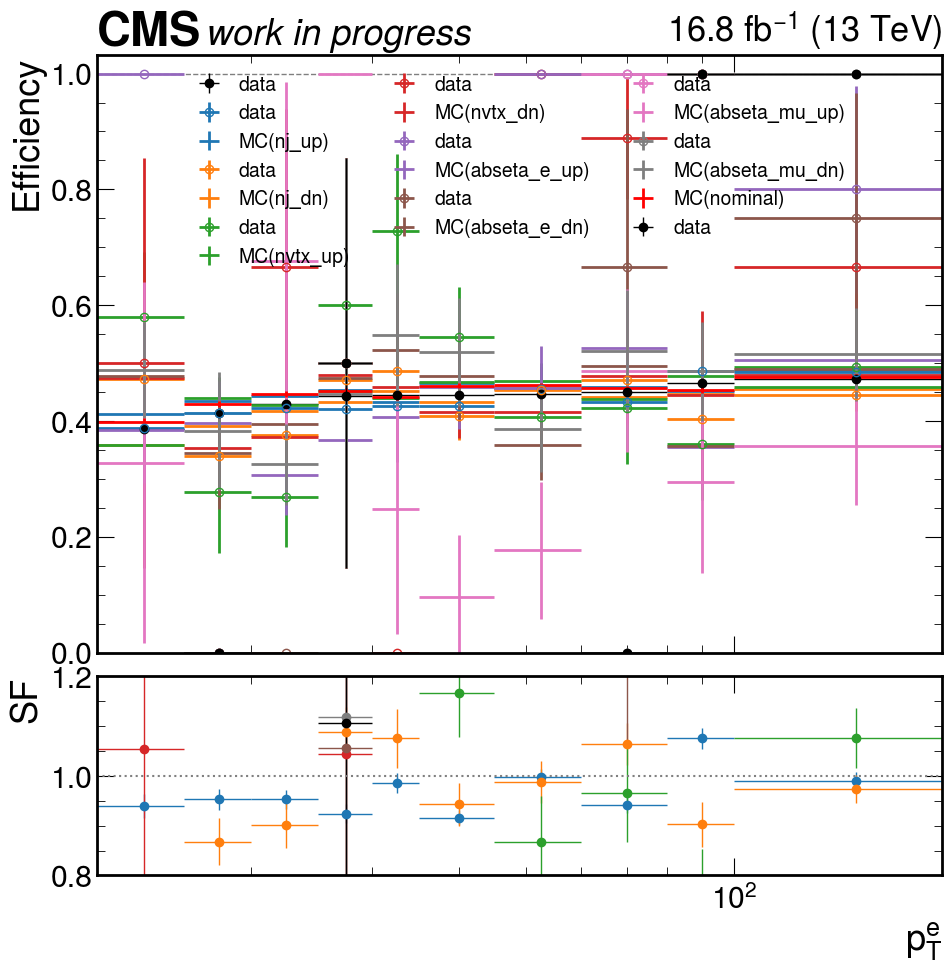

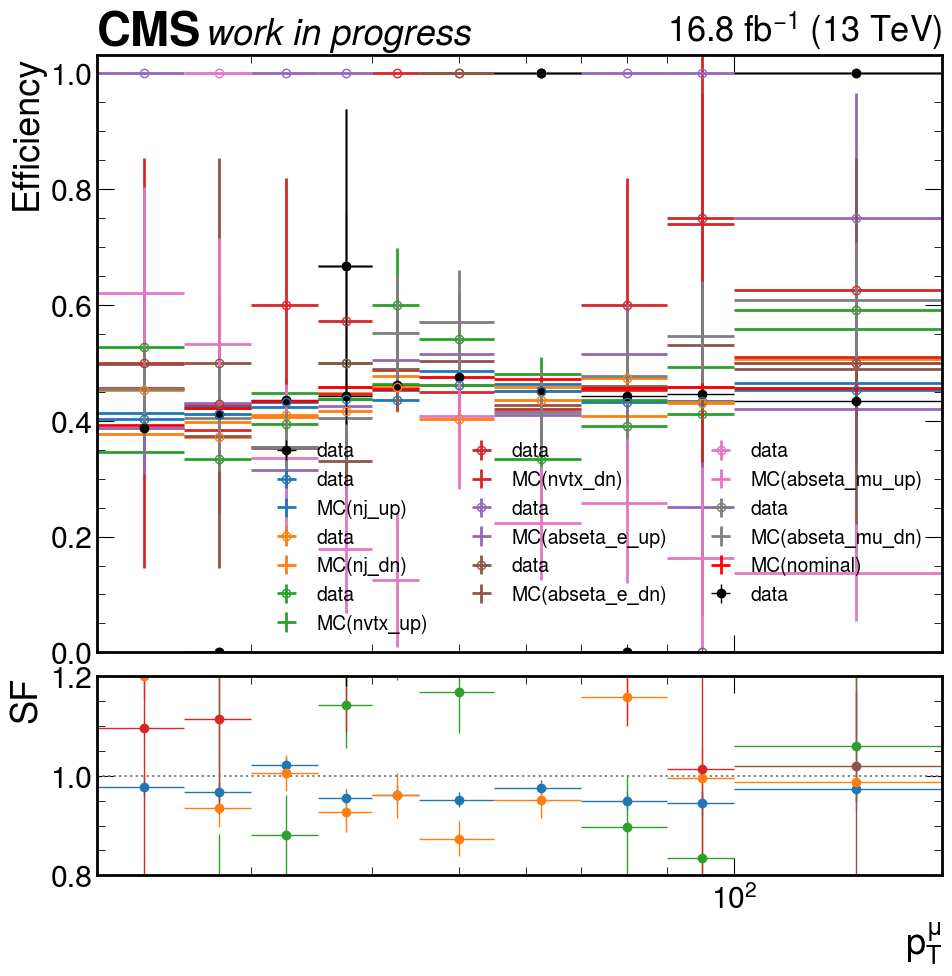

In [23]:
plt.style.use(hep.style.ROOT)


from BTVNanoCommissioning.utils.plot_utils import normal_interval
for s in collated['ttbar']['hist_all'].axes.name:
    if s=="cut" :continue
    if s!="pt_e" and s!="pt_mu" :continue
    axis={a:sum for a in collated['ttbar']['hist_all'].axes.name if s!=a}   
    for i in range(collated['data_obs']['hist_all'].axes[-1].size):
        
        axis['cut']=collated['data_obs']['hist_all'].axes[-1].value(i)
        # dump SFs
        # SF[axis['cut']]={}
        # SF[axis['cut']][s]={}
        
        if axis['cut']!='base': continue
        fig, ((ax), (rax)) = plt.subplots(
                2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
            )
        fig.subplots_adjust(hspace=0.06, top=0.92, bottom=0.1, right=0.97)
        
        hall=collated['ttbar']['hist_all'][axis]
        hMET=collated['ttbar']['hist_MET'][axis]
        
        at = AnchoredText("",  frameon=False,loc=2)
        
        for ss in color_map.keys():
            if ss == 'ttbar':continue
            hall=hall+collated[ss]['hist_all'][axis]
            hMET=hMET+collated[ss]['hist_MET'][axis]

        
        
        ax.set_ylim(0.2,0.6)
        ax.add_artist(at)
        syst_axis = axis
        _,MC,MC_err=plotratio(hall,hMET,ax=ax,
                              clear=False,unc="efficiency",label="MC(nominal)",xerr=True,
                              error_opts={"lw":2,"marker":None,"color":"r"})     
            
        _,data,data_err=plotratio(collated["data_obs"]['hist_all'][axis],
                  collated["data_obs"]['hist_MET'][axis],
                  ax=ax,unc="efficiency",
                  label="data",xerr=True
                 )
        for c,unc in enumerate(newhist.keys()):
            if "nvtx" in 
            if unc.endswith("dn"):syst_axis[unc[:-3]]=0
            else:syst_axis[unc[:-3]]=1
            hsyst_all=collated['ttbar']['hist_all'][syst_axis]
            hsyst_MET=collated['ttbar']['hist_MET'][syst_axis]
            for ss in color_map.keys():
                if ss == 'ttbar':continue
                hsyst_all=hsyst_all+collated[ss]['hist_all'][syst_axis]
                hsyst_MET=hsyst_MET+collated[ss]['hist_MET'][syst_axis]
            _,data_syst,data_syst_err=plotratio(collated["data_obs"]['hist_all'][axis],
                  collated["data_obs"]['hist_MET'][syst_axis],
                  ax=ax,unc="efficiency",
                  label="data",xerr=True,clear=False,error_opts={"lw":2,"marker":'o','markerfacecolor':"none","color":color[c]})
                 
        
            _,MC_syst,MC_syst_err=plotratio(hsyst_all,hsyst_MET,ax=ax,
                              clear=False,unc="efficiency",label=f"MC({unc})",xerr=True,
                              error_opts={"lw":2,"marker":None,"color":color[c]}) 
            rax.errorbar(
            x=hsyst_all.axes[0].centers,
            y=data_syst/MC_syst,
            xerr=(hsyst_all.axes[0].centers-hsyst_all.axes[0].edges[:-1]),
            yerr=np.sqrt(MC_syst_err**2+data_syst_err**2),lw=1,marker='o',ls="none",color=color[c])
        _,MC,MC_err=plotratio(hall,hMET,ax=ax,
                              clear=False,unc="efficiency",label="MC(nominal)",xerr=True,
                              error_opts={"lw":2,"marker":None,"color":"r"})     
            
        _,data,data_err=plotratio(collated["data_obs"]['hist_all'][axis],
                  collated["data_obs"]['hist_MET'][axis],
                  ax=ax,unc="efficiency",
                  label="data",xerr=True,clear=False
                 )
        rax.errorbar(
            x=hall.axes[0].centers,
            y=data/MC,
            xerr=(hall.axes[0].centers-hall.axes[0].edges[:-1]),
            yerr=np.sqrt(MC_err**2+data_err**2),lw=1,marker='o',ls="none",color='k')
        # for b in range(len(data/MC)):
        #     SF[axis['cut']][s][f"pt:[{hall.axes[0].edges[b]},{hall.axes[0].edges[b+1]}]"]={}
        #     SF[axis['cut']][s][f"pt:[{hall.axes[0].edges[b]},{hall.axes[0].edges[b+1]}]"]['value']=(data/MC)[b]
        #     SF[axis['cut']][s][f"pt:[{hall.axes[0].edges[b]},{hall.axes[0].edges[b+1]}]"]['stat_error']=np.sqrt(MC_err**2+data_err**2)[0][b]
        # plotratio(collated["data_obs"]['hist_all'][axis]/collated["data_obs"]['hist_MET'][axis],hmc,ax=rax)
        
        ax.legend(ncols=3,fontsize=14)
        hep.cms.label(
                "work in progress",
                data=True,
                lumi=lumi/1000,
                com="13",
                loc=0,
                ax=ax,
            )
        rax.set_ylim(0.8,1.2)
        ax.set_ylim(bottom=0)
        ax.set_xlabel(None)
        rax.set_ylabel("SF")
        ax.set_ylabel("Efficiency")
        # hep.mpl_magic(ax=ax)
        rax.axhline(1.,ls=':',color='gray')
        rax.set_xlabel(labels[s])
        if "pt" in s: ax.semilogx()
        print(np.shape(MC_err))
        # print(data/MC,np.sqrt(MC_err**2+data_err**2)[0]==np.sqrt(MC_err**2+data_err**2)[1])
        # for r in range(0,len(hall.axes[0].centers)):
        #     if "eta" in s or "nj"==s:
        #         ax.text(hall.axes[0].centers[r],0.05,round((data/MC)[r],3),size=13)
        #         ax.text(hall.axes[0].centers[r],0.035,f"$\pm${round(np.sqrt(MC_err**2+data_err**2)[0][r],3)}",size=12)
        #     else:
        #         ax.text(hall.axes[0].centers[r]-1,0.05,round((data/MC)[r],3),size=13)
        #         ax.text(hall.axes[0].centers[r]-1,0.035,f"$\pm${round(np.sqrt(MC_err**2+data_err**2)[0][r],3)}",size=12)
        plt.savefig(f"{lumi/1000}_{i}_{s}.pdf")
        # ax.set_xlim(10,100)
# hep.histplot([collated[s][axis] for s in collated.keys() if 'data' not in s],label=[s in collated.keys if 'data' not in s])

In [30]:
plt.style.use(hep.style.ROOT)


from BTVNanoCommissioning.utils.plot_utils import normal_interval
# for s in collated['ttbar']['hist_all'].axes.name:
#     # if s=="cut" :continue
# if s!="pte" and s!="ptmu" :continue
axis={a:sum for a in collated['ttbar']['hist_all'].axes.name if a !='pte' and a!='ptmu'}  

for i in range(collated['data_obs']['hist_all'].axes[-1].size):
    
    axis['cut']=collated['data_obs']['hist_all'].axes[-1].value(i)
    # print()abs
    # print(axis['cut'])
    # if i!=0:continue  
    if axis['cut']!='base': continue
    # fig, ((ax), (rax)) = plt.subplots(
    #         2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
    #     )
    # fig, ax =plt.subplots()
    # # fig.subplots_adjust(hspace=0.06, top=0.92, bottom=0.1, right=0.97)
    # hep.cms.label(
    #         "work in progress",
    #         data=True,
    #         lumi=lumi/1000,
    #         com="13",
    #         loc=0,
    #         ax=ax,
    #     )
    
    hall=collated['ttbar']['hist_all'][axis]
    hMET=collated['ttbar']['hist_MET'][axis]
    # at = AnchoredText(f"{ext[collated['data_obs']['hist_all'].axes[-1].value(i)]}\nSF",  frameon=False,loc=2)
    
    for ss in color_map.keys():
        if ss == 'ttbar':continue
        hall=hall+collated[ss]['hist_all'][axis]
        hMET=hMET+collated[ss]['hist_MET'][axis]
    # print(np.where(np.sqrt(hall.variances())/hall.values()>0.1))
    # print(hall.axes.edges)
    
    v=np.where((hall.values()==0)|(collated['data_obs']['hist_all'][axis].values()==0)
        |(np.sqrt(hall.variances())/hall.values()>0.1)|\
                (np.sqrt(collated['data_obs']['hist_all'][axis].variances())\
                 /collated['data_obs']['hist_all'][axis].values()>0.1),np.nan,collated['data_obs']['hist_all'][axis].values())
    plt.imshow(np.flip(v,axis=0))
    # rsumw_err = np.abs(
    #         normal_interval(sumw_num, sumw_denom, sumw2_num, sumw2_denom)
    #     )
    # _,data,data_err=plotratio(collated["data_obs"]['hist_all'][axis],
    #           collated["data_obs"]['hist_MET'][axis],
    #           ax=ax,unc="efficiency",
    #           label="data",xerr=True
    #          )
    
    # _,MC,MC_err=plotratio(hall,hMET,ax=ax,
    #                       clear=False,unc="efficiency",label="MC",xerr=True,
    #                       error_opts={"lw":2,"marker":None,"color":"r"})
    # ax.set_ylim(0.2,0.6)
    # ax.add_artist(at)
    # # print((hall.axes[0].edges[1:]-hall.axes[0].edges[:-1])/2.)
    # # print(hall.axes[0].centers,hall.axes[0].edges)
    # # print(MC,MC_err,np.shape(MC_err))
    # # print(np.abs(normal_interval(data, MC, data_err**2, MC_err**2)))
    # rax.errorbar(
    #     x=hall.axes[0].centers,
    #     y=data/MC,
    #     xerr=(hall.axes[0].centers-hall.axes[0].edges[:-1]),
    #     yerr=np.sqrt(MC_err**2+data_err**2),lw=1,marker='o',ls="none")
    
    # # plotratio(collated["data_obs"]['hist_all'][axis]/collated["data_obs"]['hist_MET'][axis],hmc,ax=rax)
    # ax.legend()
    # rax.set_ylim(0.9,1.1)
    # ax.set_ylim(bottom=0)
    # ax.set_xlabel(None)
    # rax.set_ylabel("SF")
    # ax.set_ylabel("Efficiency")
    # # hep.mpl_magic(ax=ax)
    # rax.axhline(1.,ls=':',color='gray')
    # rax.set_xlabel(labels[s])
    # ax.semilogx()
    # print(np.shape(MC_err))
    # # print(data/MC,np.sqrt(MC_err**2+data_err**2)[0]==np.sqrt(MC_err**2+data_err**2)[1])
    # for r in range(1,len(hall.axes[0].centers)):
    #     ax.text(hall.axes[0].centers[r]-1,0.05,round((data/MC)[r],3),size=13)
    #     ax.text(hall.axes[0].centers[r]-1,0.035,f"$\pm${round(np.sqrt(MC_err**2+data_err**2)[0][r],3)}",size=12)
        
    #     ax.set_xlim(10,100)
# hep.histplot([collated[s][axis] for s in collated.keys() if 'data' not in s],label=[s in collated.keys if 'data' not in s])

AttributeError: 'boost_histogram._core.accumulators.WeightedSum' object has no attribute 'values'

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7ff1610fd1e0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7ff16116b820>, text=[])

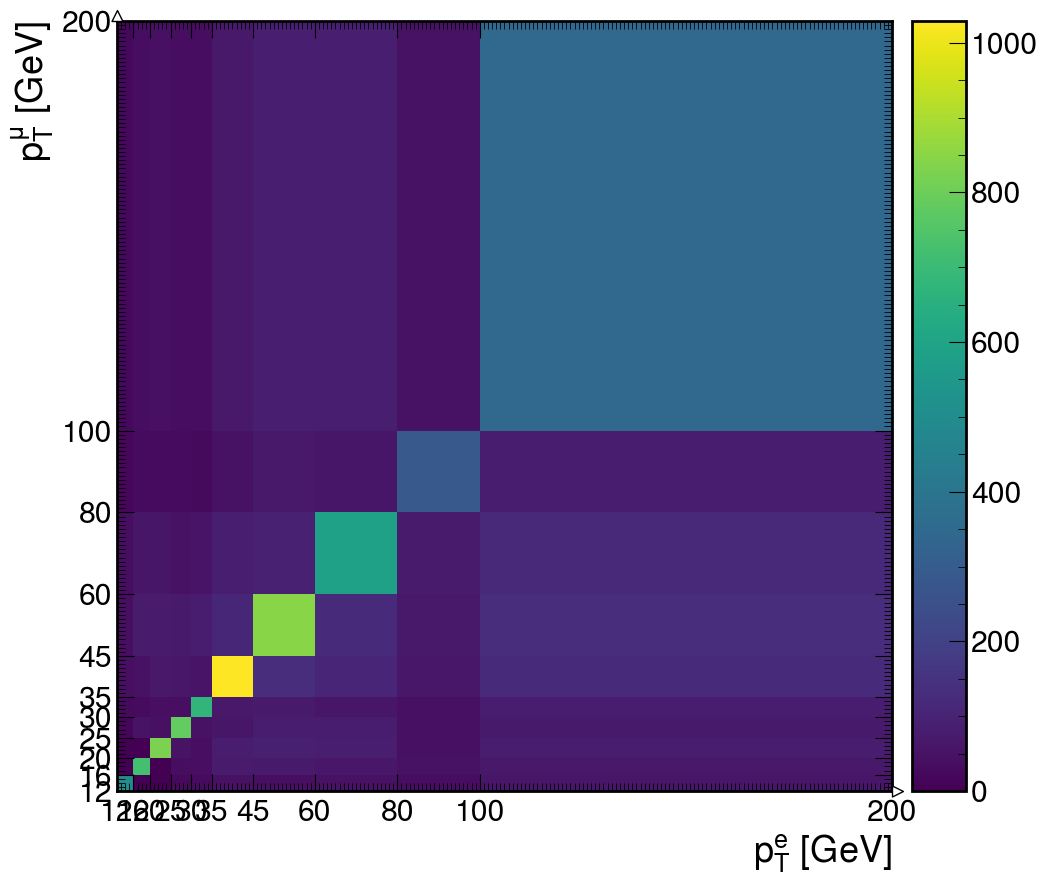

In [25]:
hep.hist2dplot(collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0])

In [ ]:
hep.hist2dplot(np.where(collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].values()==0,np.nan,collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].values()),
             collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].axes[0].edges,
              collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].axes[1].edges)

In [35]:
 collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].axes[0].edges

array([ 12.,  16.,  20.,  25.,  30.,  35.,  45.,  60.,  80., 100., 200.])

Text(64.33333333333333, 1, '$p_T^{\\mu}$')

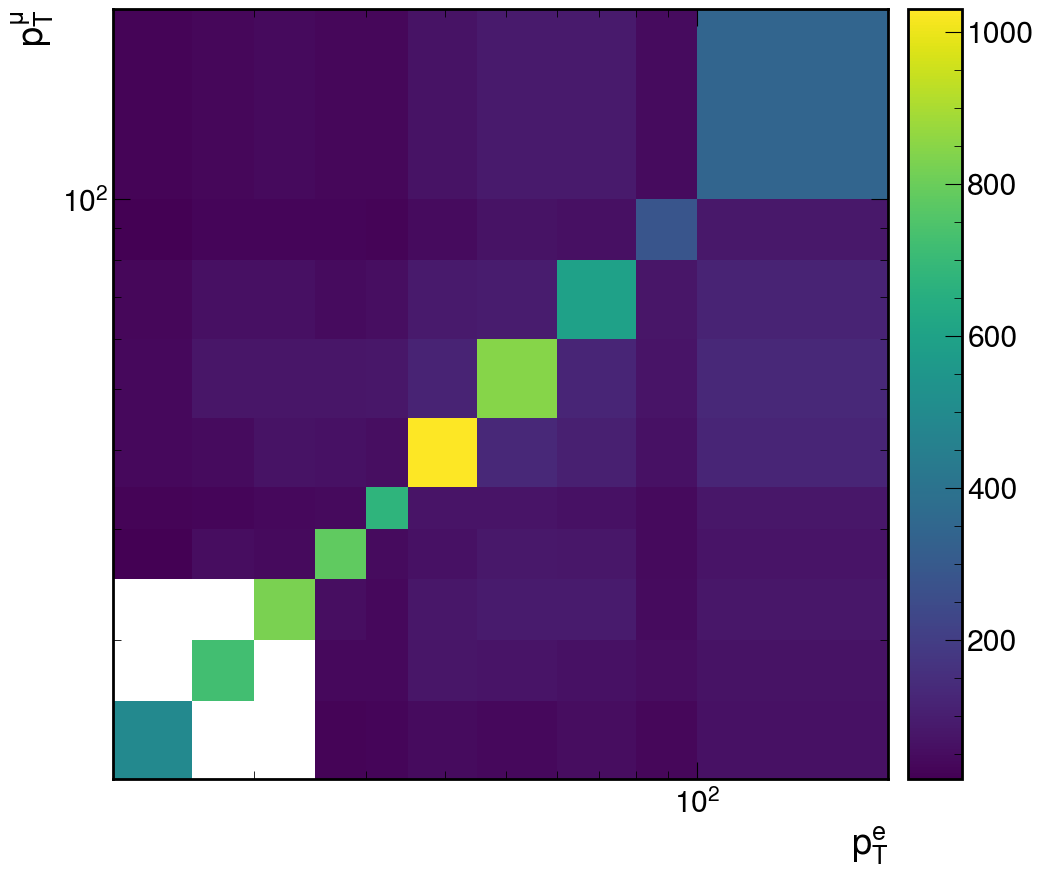

In [27]:

hep.hist2dplot(np.where(collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].values()==0,np.nan,collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].values()),
             collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].axes[0].edges,
              collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].axes[1].edges)
collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].values()
plt.semilogx()
plt.semilogy()
plt.xlabel("$p_T^{e}$")
plt.ylabel("$p_T^{\mu}$")

Text(64.33333333333333, 1, '$p_T^{\\mu}$')

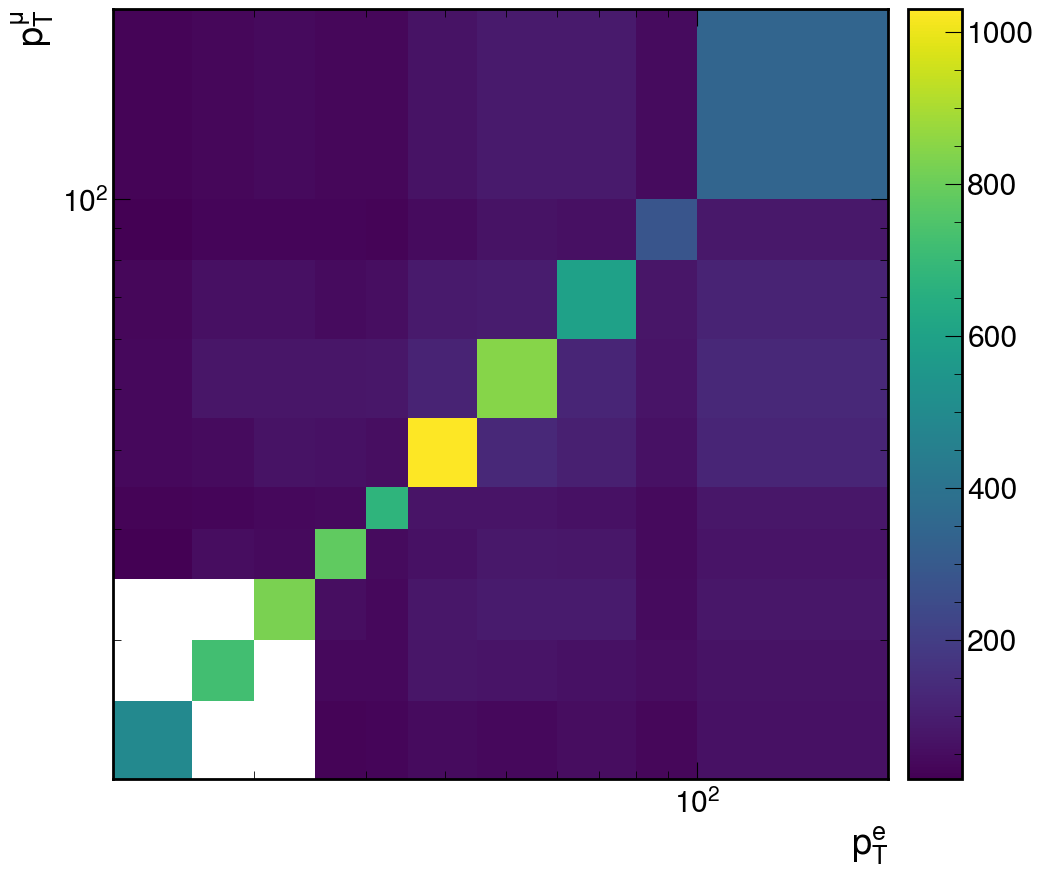

In [36]:

hep.hist2dplot(np.where(collated['MC']['hist_all'][:,:,sum,sum,sum,sum,0].values()==0,np.nan,collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].values()),
             collated['MC']['hist_all'][:,:,sum,sum,sum,sum,0].axes[0].edges,
              collated['MC']['hist_all'][:,:,sum,sum,sum,sum,0].axes[1].edges)
# collated['data_obs']['hist_all'][:,:,sum,sum,sum,sum,0].values()
plt.semilogx()
plt.semilogy()
plt.xlabel("$p_T^{e}$")
plt.ylabel("$p_T^{\mu}$")

In [119]:
from coffea.lookup_tools import extractor
ext = extractor()
ext.add_weight_sets(["* * test.histo.json"])
ext.finalize()

evaluator = ext.make_evaluator()
print("available evaluator keys:")
for key in evaluator.keys():
    print("\t", key)

print("testSF2d:", evaluator['HLT/pte_value'](7))
print("type of testSF2d:", type(evaluator['HLT/pte_value']))

available evaluator keys:
	 HLT/pte_error
	 HLT/pte_value
testSF2d: 0.9842686913959845
type of testSF2d: <class 'coffea.lookup_tools.dense_lookup.dense_lookup'>
